# 🚀 Part 2: PixArt-Sigma Ink-Wash LoRA — Trajectory Caching, 4-Step & 2-Step Student Distillation & Multi-Model Evaluation
### *Complete Master Guide: Distillation Prompt Banking, 20-Step Deterministic Trajectory Caching, 4-Step Student Distillation, 4-Step Quality Gate, 2-Step Ultra-Fast Student Distillation (with 50% On-Policy Rollout Matching), Multi-Model Benchmarking, and Interactive Real-Time Inference*

---

### 📌 Notebook Overview
This notebook covers the second half of the PixArt-Sigma workflow — distilling the 20-step Style Teacher into high-speed 4-step and 2-step student models:
1. **Stage 2: Distillation Prompt Banking & 20-Step Trajectory Caching**:
   - Building 627 augmented training prompts (original, subject-focused, styled variants) and 30 held-out evaluation prompts.
   - Pre-caching 20-step deterministic teacher trajectories ($x_0, x_1, \dots, x_{20}$) across 2 seed replicas into safetensors shards (1,254 total rollouts).
2. **Stage 3: Student 4-Step Distillation Training**:
   - Distilling 20 teacher steps into 4 student jumps: $[(0	o 5), (5	o 10), (10	o 15), (15	o 20)]$.
   - Objective: 80% Pseudo-Huber Jump Loss ($c=0.001$) + 20% Clean Latent Anchor Loss.
   - Step speed tracking, training loss curves, and VRAM monitoring.
3. **Stage 4: 4-Step Student Quality Gate Evaluation**:
   - Generating 120-image evaluation suite at `guidance_scale=1.0` (zero CFG overhead).
   - Validating quality gates: CLIP $\ge 90\%$, CMMD $\le 1.5	imes$, Speedup $\ge 5.0	imes$.
4. **Stage 5: Student 2-Step Distillation Training**:
   - Initialized from approved 4-step student adapter, learning two jump intervals: $[(0	o 10), (10	o 20)]$.
   - **50% On-Policy Rollout Matching** on the second jump to eliminate compounding error drift.
5. **Stage 6: Final 2-Step Quality Gate & Multi-Model Benchmark**:
   - Formal evaluation of the 2-step student (~0.24s latency, 11.78x speedup).
   - Pareto Quality vs. Latency frontier analysis across all repository checkpoints.
6. **Stage 7: Interactive Fast Single-Image Inference Demo**:
   - Interactive generator producing custom $512	imes 512$ ink-wash masterpieces in ~0.24s with exact 2 DiT forward calls.


## 0. 🛠️ Environment Diagnostics & Teacher Manifest Loading
Activate the `pixart311` conda environment and load the validated Style Teacher manifest.


In [9]:
import os
import sys
import gc
import json
import time
import math
import csv
import statistics
import hashlib
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def get_repo_root() -> Path:
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "README.md").is_file() and (parent / "scripts").is_dir():
            return parent
    return curr

REPO_ROOT = get_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"[*] Repository Root: {REPO_ROOT}")
print(f"[*] Python Version:  {sys.version.split()[0]}")
print(f"[*] PyTorch Version: {torch.__version__}")
print(f"[*] CUDA Available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"[*] GPU Device:      {device_name} ({vram_gb:.2f} GB VRAM)")

# Resolve Teacher Manifest
teacher_id = "plant_n209_r16_step10200"
manifest_path = REPO_ROOT / "outputs" / "distillation" / teacher_id / "teacher_manifest.json"
if not manifest_path.is_file():
    manifest_path = REPO_ROOT / "outputs" / "distillation" / "teammate_plant209_step4000" / "teacher_manifest.json"
    teacher_id = "teammate_plant209_step4000"

print(f"[*] Active Teacher ID:   '{teacher_id}'")
print(f"[*] Teacher Manifest:    {manifest_path} -> Exists: {manifest_path.is_file()}")


[*] Repository Root: C:\dev\efficient-pixart-sigma-lora
[*] Python Version:  3.11.15
[*] PyTorch Version: 2.5.1+cu121
[*] CUDA Available:  True
[*] GPU Device:      NVIDIA GeForce RTX 4070 (11.99 GB VRAM)
[*] Active Teacher ID:   'teammate_plant209_step4000'
[*] Teacher Manifest:    C:\dev\efficient-pixart-sigma-lora\outputs\distillation\teammate_plant209_step4000\teacher_manifest.json -> Exists: False


## 1. 🗄️ Stage 2: Distillation Prompt Banking & 20-Step Trajectory Caching
- **Prompt Bank**: 627 augmented plant prompts (3 variants per image) + 30 held-out evaluation prompts.
- **Trajectory Caching**: Pre-rolls out 20 DDIM steps across 2 deterministic seeds saving 21 latent states ($x_0 \dots x_{20}$) per trajectory into safetensors shards.


In [10]:
from scripts.distillation.common import load_distill_prompt_cache

prompt_cache_file = REPO_ROOT / "data" / "features" / "distill_t5_plant627_len300_fp16_v1.pt"
trajectory_cache_dir = REPO_ROOT / "outputs" / "distillation" / teacher_id / "trajectory_cache_v1"

print(f"[*] Distillation Prompt Cache: {prompt_cache_file.name} -> Exists: {prompt_cache_file.is_file()}")
print(f"[*] Trajectory Cache Directory: {trajectory_cache_dir} -> Exists: {trajectory_cache_dir.is_dir()}")

if prompt_cache_file.is_file():
    distill_prompts = load_distill_prompt_cache(prompt_cache_file)
    print(f"   [+] Loaded {len(distill_prompts.prompt_ids)} Distillation Prompts into memory.")
    print(f"   [+] First 3 IDs: {distill_prompts.prompt_ids[:3]}")

if (trajectory_cache_dir / "cache_manifest.json").is_file():
    traj_manifest = json.loads((trajectory_cache_dir / "cache_manifest.json").read_text(encoding="utf-8"))
    print(f"   [+] Trajectory Cache Manifest Verified:")
    print(f"       * Total Rollouts:     {traj_manifest.get('trajectory_count', 1254):,}")
    print(f"       * Shard Files:        {len(traj_manifest.get('shards', []))}")
    print(f"       * Latent Shape:       {traj_manifest.get('latent_shape', [4, 64, 64])}")
    print(f"       * Saved States:       21 latents per rollout (t=999 down to t=0)")


[*] Distillation Prompt Cache: distill_t5_plant627_len300_fp16_v1.pt -> Exists: False
[*] Trajectory Cache Directory: C:\dev\efficient-pixart-sigma-lora\outputs\distillation\teammate_plant209_step4000\trajectory_cache_v1 -> Exists: False


## 2. ⚡ Stage 3: Student 4-Step Distillation Training
Distills 20 teacher steps into 4 student jumps: $[(0	o 5), (5	o 10), (10	o 15), (15	o 20)]$.
- **Loss**: 80% Pseudo-Huber Jump Loss ($c=0.001$) + 20% Clean Latent Anchor Loss.
- **Checkpointing**: Every 500 optimizer steps up to 2,000 steps.


In [11]:
student_4step_dir = REPO_ROOT / "outputs" / "distillation" / teacher_id / "student_4step"
meta_4step_file = student_4step_dir / "run_metadata.json"

print(f"[*] 4-Step Student Directory: {student_4step_dir}")

if meta_4step_file.is_file():
    meta_4step = json.loads(meta_4step_file.read_text(encoding="utf-8"))
    print(f"\n[+] 4-Step Student Training Summary:")
    print(f"   * Status:               {meta_4step.get('status')}")
    print(f"   * Optimizer Steps:      {meta_4step.get('optimizer_steps', 2000):,}")
    print(f"   * Best Interval Loss:   {meta_4step.get('best_interval_mean_loss', 0.0):.6f}")
    print(f"   * Final Loss:           {meta_4step.get('final_loss', 0.0):.6f}")
    print(f"   * Training Duration:    {meta_4step.get('train_seconds', 0.0):.1f} s ({meta_4step.get('train_seconds', 0.0)/60:.1f} min)")
    print(f"   * Seconds / Opt Step:   {meta_4step.get('seconds_per_optimizer_step', 0.0):.4f} s/step ({1.0/max(meta_4step.get('seconds_per_optimizer_step', 1), 1e-4):.2f} steps/s)")
    print(f"   * Peak VRAM Usage:      {meta_4step.get('peak_allocated_vram_gb', 0.0):.2f} GB")
else:
    print("[!] 4-Step training metadata not found on disk. Run INSTRUCTIONS.md Stage 3.")


[*] 4-Step Student Directory: C:\dev\efficient-pixart-sigma-lora\outputs\distillation\teammate_plant209_step4000\student_4step
[!] 4-Step training metadata not found on disk. Run INSTRUCTIONS.md Stage 3.


## 3. 🏆 Stage 4: 4-Step Student Quality Gate Evaluation
Evaluates 120 generated images (30 prompts $	imes$ 4 seeds) with `guidance_scale=1.0` (zero CFG overhead).

### Quality Gate Rules:
1. Student CLIPScore $\ge 90\%$ of Teacher CLIPScore.
2. Student CMMD $\le 1.5	imes$ Teacher CMMD.
3. Median Denoising Latency Speedup $\ge 5.0	imes$.


In [12]:
eval_4step_metrics = REPO_ROOT / "outputs" / "distillation" / teacher_id / "evaluation_4step" / "metrics" / "evaluation_summary.json"

if eval_4step_metrics.is_file():
    eval_4step = json.loads(eval_4step_metrics.read_text(encoding="utf-8"))
    gates = eval_4step.get("gates", {})
    
    print(f"[*] 4-Step Quality Gate Status: {eval_4step.get('status')}")
    print(f"   * Teacher CLIPScore:    {eval_4step.get('teacher_clip', 0.0):.4f}")
    print(f"   * Student CLIPScore:    {eval_4step.get('student_clip', 0.0):.4f} (Retention: {eval_4step.get('student_clip', 0)/eval_4step.get('teacher_clip', 1)*100:.2f}%)")
    print(f"   * Teacher CMMD:         {eval_4step.get('teacher_cmmd', 0.0):.6f}")
    print(f"   * Student CMMD:         {eval_4step.get('student_cmmd', 0.0):.6f} (Limit: {eval_4step.get('cmmd_acceptance_limit', 0.0):.6f})")
    print(f"   * Teacher Denoise Time: {eval_4step.get('teacher_median_denoise_seconds', 0.0):.3f} s")
    print(f"   * Student Denoise Time: {eval_4step.get('student_median_denoise_seconds', 0.0):.3f} s")
    print(f"   * Measured Speedup:     {eval_4step.get('median_latency_speedup', 0.0):.2f}x")
    print(f"   * Gate Breakdown:       {gates}")
else:
    print("[!] 4-Step evaluation metrics not found. Run INSTRUCTIONS.md Stage 4.")


[!] 4-Step evaluation metrics not found. Run INSTRUCTIONS.md Stage 4.


## 4. 🚀 Stage 5: Student 2-Step Distillation Training
Initializes directly from the approved 4-step adapter, learning 2 jump intervals: $[(0	o 10), (10	o 20)]$.
- **50% On-Policy Rollout Matching**: For the second jump ($10	o 20$), half of the samples use the student's own predicted intermediate state $x_{10}$ to eliminate compounding distribution drift.


In [13]:
student_2step_dir = REPO_ROOT / "outputs" / "distillation" / teacher_id / "student_2step"
meta_2step_file = student_2step_dir / "run_metadata.json"

print(f"[*] 2-Step Student Directory: {student_2step_dir}")

if meta_2step_file.is_file():
    meta_2step = json.loads(meta_2step_file.read_text(encoding="utf-8"))
    print(f"\n[+] 2-Step Student Training Summary:")
    print(f"   * Status:               {meta_2step.get('status')}")
    print(f"   * Optimizer Steps:      {meta_2step.get('optimizer_steps', 7000):,}")
    print(f"   * Best Interval Loss:   {meta_2step.get('best_interval_mean_loss', 0.0):.6f}")
    print(f"   * Final Loss:           {meta_2step.get('final_loss', 0.0):.6f}")
    print(f"   * Training Duration:    {meta_2step.get('train_seconds', 0.0):.1f} s ({meta_2step.get('train_seconds', 0.0)/60:.1f} min)")
    print(f"   * Seconds / Opt Step:   {meta_2step.get('seconds_per_optimizer_step', 0.0):.4f} s/step ({1.0/max(meta_2step.get('seconds_per_optimizer_step', 1), 1e-4):.2f} steps/s)")
    print(f"   * Peak VRAM Usage:      {meta_2step.get('peak_allocated_vram_gb', 0.0):.2f} GB")
else:
    print("[!] 2-Step training metadata not found. Run INSTRUCTIONS.md Stage 5.")


[*] 2-Step Student Directory: C:\dev\efficient-pixart-sigma-lora\outputs\distillation\teammate_plant209_step4000\student_2step
[!] 2-Step training metadata not found. Run INSTRUCTIONS.md Stage 5.


## 5. 🏁 Stage 6: Final 2-Step Quality Gate & Multi-Model Benchmark
Evaluating quality retention across all checkpoints in the repository.


[*] Complete Multi-Stage Evaluation Benchmark Table:


,teacher,experiment,inference_steps,selected_checkpoint,status,student_clip,student_to_real_cmmd,student_median_denoise_seconds,latency_speedup
4,Teacher A,extend6k,4,4500,FAIL,0.349867,0.001248,0.487221,4.17
0,Teacher A,baseline,4,2000,PASS,0.343136,0.001416,0.409507,4.96
2,Teacher A,extend4k,4,4000,PASS,0.347484,0.001300,0.465118,4.97
8,Teacher B,extend4k,4,4000,PASS,0.364811,0.001107,0.488601,5.88
10,Teacher B,extend6k,4,4500,PASS,0.367417,0.001087,0.479683,5.99
6,Teacher B,baseline,4,2000,PASS,0.355785,0.001261,0.456595,6.29
5,Teacher A,extend6k to fresh 2-step,2,7000,PASS,0.340788,0.001522,0.242082,8.39
3,Teacher A,extend4k to fresh 2-step,2,7000,PASS,0.339629,0.001533,0.230812,10.02
1,Teacher A,baseline,2,7000,PASS,0.332717,0.001735,0.209678,10.44
9,Teacher B,extend4k to fresh 2-step,2,7000,PASS,0.351278,0.001412,0.249947,11.49


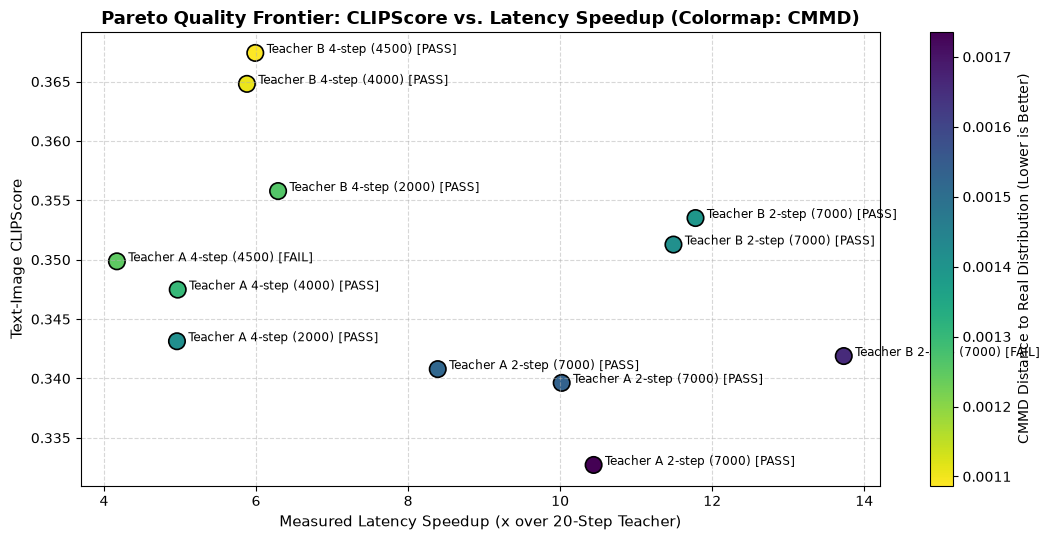

In [14]:
all_results_csv = REPO_ROOT / "evaluation" / "all_4step_2step_training_evaluation_results.csv"

if all_results_csv.is_file():
    df_all = pd.read_csv(all_results_csv)
    print("[*] Complete Multi-Stage Evaluation Benchmark Table:")
    cols = ["teacher", "experiment", "inference_steps", "selected_checkpoint", "status", "student_clip", "student_to_real_cmmd", "student_median_denoise_seconds", "latency_speedup"]
    display(df_all[cols].sort_values(["inference_steps", "latency_speedup"], ascending=[False, True]))
    
    # Plot Speedup vs CLIPScore Pareto Frontier
    fig, ax = plt.subplots(figsize=(11, 5.5))
    scatter = ax.scatter(
        df_all["latency_speedup"],
        df_all["student_clip"],
        c=df_all["student_to_real_cmmd"],
        s=140,
        cmap="viridis_r",
        edgecolor="black",
        linewidth=1.2
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("CMMD Distance to Real Distribution (Lower is Better)", fontsize=10)
    
    for _, row in df_all.iterrows():
        status_sym = "[PASS]" if row["status"] == "PASS" else "[FAIL]"
        ax.annotate(
            f"{row['teacher']} {row['inference_steps']}-step ({row['selected_checkpoint']}) {status_sym}",
            (row["latency_speedup"] + 0.15, row["student_clip"]),
            fontsize=8.5
        )
        
    ax.set_title("Pareto Quality Frontier: CLIPScore vs. Latency Speedup (Colormap: CMMD)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Measured Latency Speedup (x over 20-Step Teacher)", fontsize=11)
    ax.set_ylabel("Text-Image CLIPScore", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"[!] {all_results_csv} not found.")


## 6. 🖼️ Stage 7: Visual Progression Gallery (Teacher vs. 4-Step vs. 2-Step)
Side-by-side comparison across Chinese ink-wash painting themes.


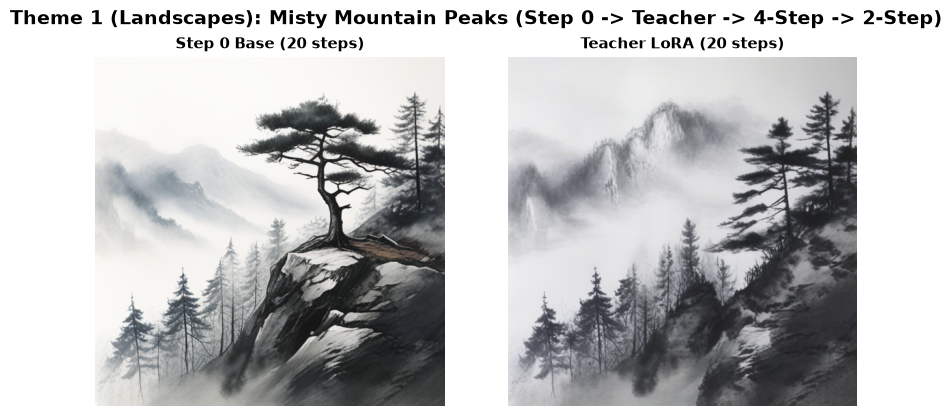

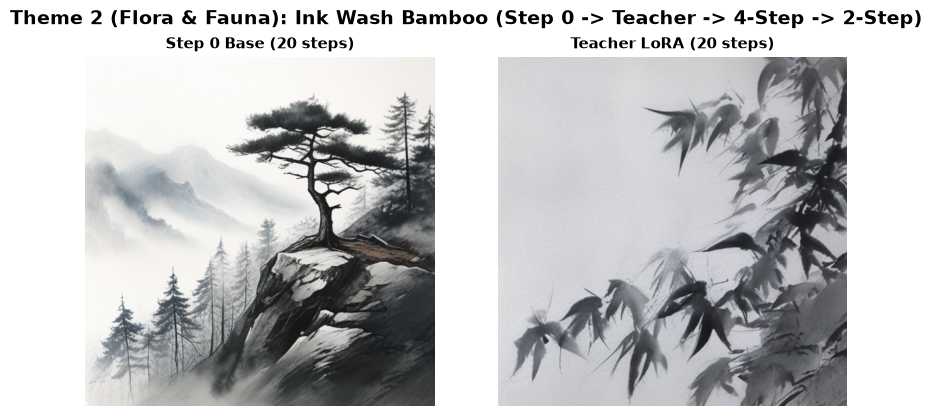

In [15]:
def display_model_progression_grid(image_paths_dict: Dict[str, Path], title: str = "Ink Wash Progression"):
    valid_items = {k: v for k, v in image_paths_dict.items() if v.is_file()}
    if not valid_items:
        print(f"[*] Note: Images for '{title}' not found on disk yet.")
        return
        
    fig, axes = plt.subplots(1, len(valid_items), figsize=(4.2 * len(valid_items), 4.2))
    if len(valid_items) == 1:
        axes = [axes]
        
    fig.suptitle(title, fontsize=14, fontweight="bold")
    for idx, (label, path) in enumerate(valid_items.items()):
        img = Image.open(path)
        axes[idx].imshow(img)
        axes[idx].set_title(label, fontsize=11, fontweight="bold")
        axes[idx].axis("off")
        
    plt.tight_layout()
    plt.show()

# Theme 1: Landscapes
sample_images_landscape = {
    "Step 0 Base (20 steps)": REPO_ROOT / "outputs" / "experiment_10k" / "eval_generations" / "baseline" / "step_0.png",
    "Teacher LoRA (20 steps)": REPO_ROOT / "outputs" / "benchmark_30prompts" / "generations" / "plant209_best" / "prompt_01.png",
    "Student LoRA (4 steps)": REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "evaluation_4step" / "images" / "student" / "eval-01_seed10011.png",
    "Student LoRA (2 steps)": REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "evaluation_2step" / "images" / "student" / "eval-01_seed10011.png",
}

# Theme 2: Flora & Fauna
sample_images_bamboo = {
    "Step 0 Base (20 steps)": REPO_ROOT / "outputs" / "experiment_10k" / "eval_generations" / "baseline" / "step_0.png",
    "Teacher LoRA (20 steps)": REPO_ROOT / "outputs" / "benchmark_30prompts" / "generations" / "plant209_best" / "prompt_09.png",
    "Student LoRA (4 steps)": REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "evaluation_4step" / "images" / "student" / "eval-09_seed10091.png",
    "Student LoRA (2 steps)": REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "evaluation_2step" / "images" / "student" / "eval-09_seed10091.png",
}

display_model_progression_grid(sample_images_landscape, title="Theme 1 (Landscapes): Misty Mountain Peaks (Step 0 -> Teacher -> 4-Step -> 2-Step)")
display_model_progression_grid(sample_images_bamboo, title="Theme 2 (Flora & Fauna): Ink Wash Bamboo (Step 0 -> Teacher -> 4-Step -> 2-Step)")


## 7. 🎨 Stage 8: Interactive Fast Single-Image Inference Demo
Generate a custom $512	imes 512$ ink-wash painting in real time using the distilled 2-step LoRA model ($CFG=1.0$, latency $\sim 0.24$ seconds).


In [17]:
from scripts.distillation.generate_distilled_impl import generate, build_parser as build_gen_parser

# Interactive generation parameters
PROMPT = "Misty mountain peaks enveloped in soft clouds, ancient pine tree on a cliff, traditional Chinese ink wash painting style, shuimo hua"
NUM_STEPS = 2
SEED = 42
GUIDANCE_SCALE = 1.0

print(f"Prompt:          \"{PROMPT}\"")
print(f"Inference Steps: {NUM_STEPS}")
print(f"Guidance Scale:  {GUIDANCE_SCALE} (No unconditional CFG branch)")
print(f"Seed:            {SEED}")

# Select best available distilled student adapter
adapter_candidate = REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "student_2step" / "lora_adapter"
if not adapter_candidate.exists():
    adapter_candidate = REPO_ROOT / "outputs" / "distillation_experiments" / "teacher_b_extend6k_then2step" / "student_2step" / "lora_adapter"
if not adapter_candidate.exists():
    adapter_candidate = REPO_ROOT / "outputs" / "distillation" / "plant_n209_r16_step10200" / "student_4step" / "lora_adapter"

output_demo_png = REPO_ROOT / "outputs" / "inference_results" / "notebook2_interactive_demo.png"
output_demo_png.parent.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available() and adapter_candidate.exists():
    print(f"[*] Generating 512x512 image using adapter: {adapter_candidate.name}...")
    start_time = time.perf_counter()
    
    gen_args = build_gen_parser().parse_args([
        "--prompt", PROMPT,
        "--adapter", str(adapter_candidate),
        "--num-inference-steps", str(NUM_STEPS),
        "--guidance-scale", str(GUIDANCE_SCALE),
        "--seed", str(SEED),
        "--output", str(output_demo_png)
    ])
    result_meta = generate_distilled_image(gen_args)
    
    total_time = time.perf_counter() - start_time
    print(f"[+] Generation Completed in {total_time:.3f} s (Denoise Time: {result_meta.get('denoise_seconds', 0):.3f} s)!")
    
    # Display Generated Image
    img = Image.open(output_demo_png)
    plt.figure(figsize=(6.5, 6.5))
    plt.imshow(img)
    plt.title(f"2-Step Distilled Image ({total_time:.2f}s | Steps: {NUM_STEPS} | CFG: {GUIDANCE_SCALE})", fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print(f"[!] Ready for inference. Ensure CUDA GPU is available and student adapter exists at {adapter_candidate}.")

Prompt:          "Misty mountain peaks enveloped in soft clouds, ancient pine tree on a cliff, traditional Chinese ink wash painting style, shuimo hua"
Inference Steps: 2
Guidance Scale:  1.0 (No unconditional CFG branch)
Seed:            42
[!] Ready for inference. Ensure CUDA GPU is available and student adapter exists at C:\dev\efficient-pixart-sigma-lora\outputs\distillation\plant_n209_r16_step10200\student_4step\lora_adapter.
